In [5]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from tqdm import tqdm



df = pd.read_csv("arXiv_scientific_dataset.csv")
df = df.head(20000)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [6]:
df.head()

,id,title,category,category_code,published_date,updated_date,authors,first_author,summary,summary_word_count
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,cs.AI,8/1/93,8/1/93,['M. L. Ginsberg'],'M. L. Ginsberg',Because of their occasional need to return to ...,79
1,cs-9308102v1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,cs.AI,8/1/93,8/1/93,['M. P. Wellman'],'M. P. Wellman',Market price systems constitute a well-underst...,119
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,cs.AI,9/1/93,9/1/93,"['I. P. Gent', 'T. Walsh']",'I. P. Gent',We describe an extensive study of search in GS...,167
3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,cs.AI,11/1/93,11/1/93,"['F. Bergadano', 'D. Gunetti', 'U. Trinchero']",'F. Bergadano',As real logic programmers normally use cut (!)...,174
4,cs-9311102v1,Software Agents: Completing Patterns and Const...,Artificial Intelligence,cs.AI,11/1/93,11/1/93,"['J. C. Schlimmer', 'L. A. Hermens']",'J. C. Schlimmer',To support the goal of allowing users to recor...,187


In [7]:

df.shape

(20000, 10)

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  20000 non-null  object
 1   title               20000 non-null  object
 2   category            20000 non-null  object
 3   category_code       20000 non-null  object
 4   published_date      20000 non-null  object
 5   updated_date        20000 non-null  object
 6   authors             20000 non-null  object
 7   first_author        20000 non-null  object
 8   summary             20000 non-null  object
 9   summary_word_count  20000 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


In [9]:

df.isnull().sum()

id                    0
title                 0
category              0
category_code         0
published_date        0
updated_date          0
authors               0
first_author          0
summary               0
summary_word_count    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

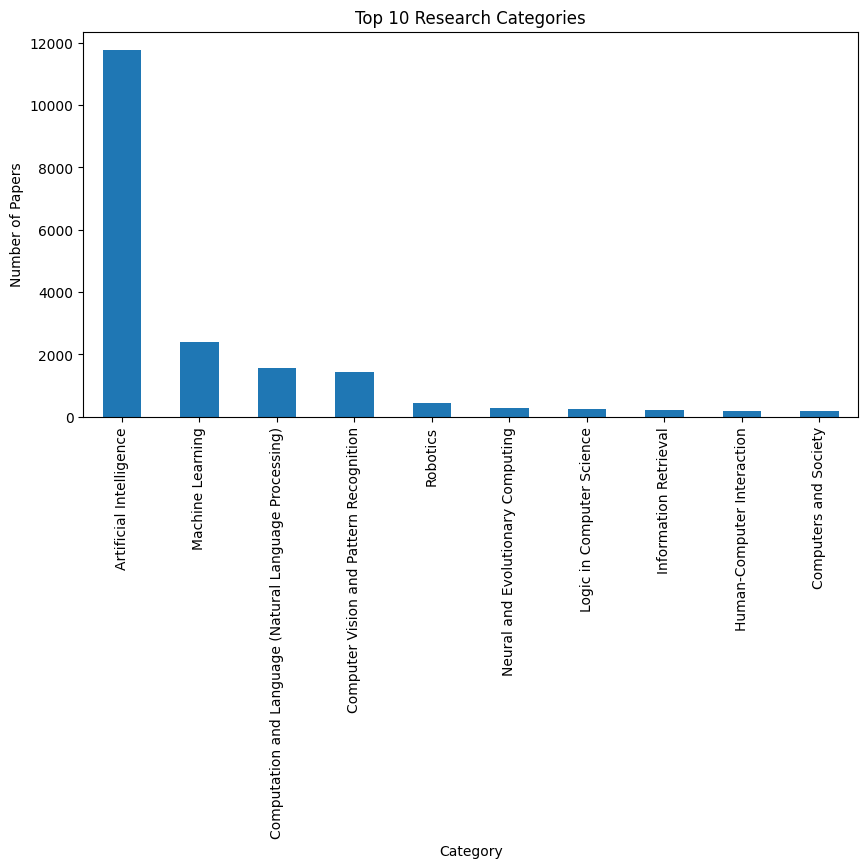

In [11]:
df = df.drop_duplicates()

df = df.dropna(subset=["title", "summary"])

df.reset_index(drop=True, inplace=True)



plt.figure(figsize=(10,5))

df["category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Research Categories")
plt.xlabel("Category")
plt.ylabel("Number of Papers")

plt.xticks

plt.show()

In [1]:

import re
import string

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

In [2]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [12]:

df["processed_text"] = (
    df["title"] + " " + df["summary"]
).apply(preprocess)

df[["title", "processed_text"]].head()

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df["processed_text"].tolist()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:

embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True  
)


embeddings.shape

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [ ]:
np.save("embeddings.npy", embeddings)
embeddings = np.load("embeddings.npy")

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMean

In [ ]:
pca = PCA(n_components=2)

pca_embeddings = pca.fit_transform(embeddings)

pca_embeddings.shape


plt.figure(figsize=(8,6))

In [ ]:

plt.scatter(
    pca_embeddings[:,0],
    pca_embeddings[:,1],
    s=8,
    alpha=0.6
)
plt.title("PCA Projection of Research Papers")

In [ ]:
plt.xlabel("Principal Component 1")

In [ ]:

plt.ylabel("Principal Component 2")


In [ ]:
plt.show()


In [ ]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

clusters = kmeans.fit_predict(embeddings)


df["Cluster"] = clusters

df[["title","category","Cluster"]].head()

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_embeddings[:,0],
    pca_embeddings[:,1],
    c=clusters,
    s=8
)
plt.title("K-Means Clusters")

In [ ]:
plt.xlabel("Principal Component 1")

In [ ]:

plt.ylabel("Principal Component 2")

In [ ]:
plt.show()

In [ ]:
df["Cluster"].value_counts().sort_index()

In [ ]:
import faiss



dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)


In [ ]:
def search_papers(query, top_k=5):

    query_embedding = model.encode([preprocess(query)])

    distances, indices = index.search(query_embedding, top_k)

    return df.iloc[indices[0]][["title", "category", "authors"]]



search_papers("Deep Learning for Medical Image Analysis")



search_papers("Cyber Security using Artificial Intelligence")

In [ ]:

def recommend_papers(paper_index, top_k=5):

    distances, indices = index.search(
        embeddings[paper_index].reshape(1,-1),
        top_k + 1
    )

    recommendations = df.iloc[
        indices[0][1:]
    ][["title","category","authors"]]

    return recommendations




faiss.write_index(index, "faiss_index.index")

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")


sample_text = df.loc[7, "summary"]

doc = nlp(sample_text)

print(sample_text)


In [ ]:

entities = []

for ent in doc.ents:
    entities.append([ent.text, ent.label_])

entity_df = pd.DataFrame(
    entities,
    columns=["Entity", "Type"]
)

entity_df



entity_df["Type"].value_counts()

In [ ]:

def extract_entities(text):

    doc = nlp(text)

    return [
        (ent.text, ent.label_)
        for ent in doc.ents
    ]

df.loc[:99, "Entities"] = df.loc[:99, "summary"].apply(extract_entities)

df[["title", "Entities"]].head()

In [ ]:

from keybert import KeyBERT


kw_model = KeyBERT(model)

sample_text = df.loc[7, "summary"]

keywords = kw_model.extract_keywords(
    sample_text,
    keyphrase_ngram_range=(1,2),
    stop_words="english",
    top_n=10
)

keyword_df = pd.DataFrame(
    keywords,
    columns=["Keyword","Score"]
)




def extract_keywords(text):
    return kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1,2),
        stop_words="english",
        top_n=5
    )




keyword_df = df.head(100).copy()

keyword_df["Keywords"] = keyword_df["summary"].apply(extract_keywords)

keyword_df.loc[7, ["title", "Keywords"]]


In [ ]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["category"])


X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    y,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



clf = SGDClassifier(
    loss="log_loss",
    max_iter=300,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

accuracy_score(y_test, y_pred)


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    labels=range(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))

In [ ]:
sns.heatmap(cm, cmap="Blues")

In [ ]:
plt.title("Confusion Matrix - Category Classification")

In [ ]:
plt.xlabel("Predicted")

In [ ]:
plt.ylabel("Actual")

In [ ]:
plt.show()

In [ ]:

from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    framework="pt",
    device=0
)


sample_text = df.loc[7, "summary"]

summary = summarizer(
    sample_text,
    max_length=60,
    min_length=20,
    do_sample=False
)

summary[0]["summary_text"]



def summarize_texts_batch(text_list):
    summaries = summarizer(
        text_list,
        max_length=60,
        min_length=20,
        num_beams=1,
        do_sample=False,
        batch_size=4
    ) 
    return [s["summary_text"] for s in summaries]

In [ ]:

summary_df = df.head(20).copy()

summary_df["Generated_Summary"] = summarize_texts_batch(summary_df["summary"].tolist())




summary_df[["title", "summary", "Generated_Summary"]]



qa_pipeline = pipeline(
    "question-answering",
    model="distilbert-base-cased-distilled-squad"

In [ ]:

paper = df.loc[7, "summary"]

questions = [
    "What is the objective of this research?",
    "What challenge is addressed in this paper?",
    "What approach is introduced?",
    "What are the key findings?",
    "What technique is used in this study?"
]

for q in questions:
    print(f"Question: {q}")
    print("Answer:", answer_question(q, paper))

In [ ]:
def answer_question(question, context):
    result = qa_pipeline(
        question=question,
        context=context
    )
    return result["answer"]




answer_question(
    "What method is used in this research?",
    df.loc[7, "summary"]
)

In [ ]:

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)


In [ ]:
print("Total Papers:", len(df))
print("Categories:", df["category"].nunique())
print("Clusters:", df["Cluster"].nunique())
print("Embedding Dimension:", embeddings.shape[1])
print("FAISS Index Size:", index.ntotal)
print("Classification Accuracy:", round(accuracy * 100, 2), "%")
